## AGUME KENNETH B30309

- loading the necessary libraries

In [12]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


Question 1.Understanding the traffic density on various days of the week in the urban environments. [ 5 
MARKS ]

In [3]:
traffic = pd.read_csv('traffic_Data.csv')
traffic

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,SolarisVille,Drone,Snowy,Stable,Sunday,20,29.4268,0,0,14.7134,0.5241
1,AquaCity,Flying Car,Solar Flare,Recession,Wednesday,2,118.8000,0,0,143.5682,0.3208
2,Neuroburg,Autonomous Vehicle,Solar Flare,Recession,Wednesday,16,100.3904,0,0,91.2640,0.0415
3,Ecoopolis,Drone,Clear,Booming,Thursday,8,76.8000,1,0,46.0753,0.1811
4,AquaCity,Autonomous Vehicle,Solar Flare,Stable,Saturday,16,45.2176,0,0,40.1934,0.4544
...,...,...,...,...,...,...,...,...,...,...,...
1219562,SolarisVille,Autonomous Vehicle,Electromagnetic Storm,Booming,Wednesday,13,75.7534,0,0,60.6027,0.3840
1219563,MetropolisX,Drone,Snowy,Booming,Saturday,1,24.7660,0,0,14.8122,0.5526
1219564,Neuroburg,Autonomous Vehicle,Snowy,Booming,Monday,19,75.6292,0,0,61.8568,0.0564
1219565,MetropolisX,Autonomous Vehicle,Clear,Booming,Monday,1,52.7983,0,0,85.7116,0.5079


In [4]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1219567 entries, 0 to 1219566
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   City                   1219567 non-null  object 
 1   Vehicle Type           1219567 non-null  object 
 2   Weather                1219567 non-null  object 
 3   Economic Condition     1219567 non-null  object 
 4   Day Of Week            1219567 non-null  object 
 5   Hour Of Day            1219567 non-null  int64  
 6   Speed                  1219567 non-null  float64
 7   Is Peak Hour           1219567 non-null  int64  
 8   Random Event Occurred  1219567 non-null  int64  
 9   Energy Consumption     1219567 non-null  float64
 10  Traffic Density        1219567 non-null  float64
dtypes: float64(3), int64(3), object(5)
memory usage: 102.4+ MB


- finding if my data has missing values

In [5]:
traffic.isnull().sum()

City                     0
Vehicle Type             0
Weather                  0
Economic Condition       0
Day Of Week              0
Hour Of Day              0
Speed                    0
Is Peak Hour             0
Random Event Occurred    0
Energy Consumption       0
Traffic Density          0
dtype: int64

- finding if my data has duplicated values

In [7]:
traffic.duplicated().sum()

np.int64(0)

- Splitting my data into continous and categorical

In [8]:
cont_data = traffic.select_dtypes(exclude=['object'])
cont_data

,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,20,29.4268,0,0,14.7134,0.5241
1,2,118.8000,0,0,143.5682,0.3208
2,16,100.3904,0,0,91.2640,0.0415
3,8,76.8000,1,0,46.0753,0.1811
4,16,45.2176,0,0,40.1934,0.4544
...,...,...,...,...,...,...
1219562,13,75.7534,0,0,60.6027,0.3840
1219563,1,24.7660,0,0,14.8122,0.5526
1219564,19,75.6292,0,0,61.8568,0.0564
1219565,1,52.7983,0,0,85.7116,0.5079


In [9]:
cat_data =traffic.select_dtypes(include=['object'])
cat_data

,City,Vehicle Type,Weather,Economic Condition,Day Of Week
0,SolarisVille,Drone,Snowy,Stable,Sunday
1,AquaCity,Flying Car,Solar Flare,Recession,Wednesday
2,Neuroburg,Autonomous Vehicle,Solar Flare,Recession,Wednesday
3,Ecoopolis,Drone,Clear,Booming,Thursday
4,AquaCity,Autonomous Vehicle,Solar Flare,Stable,Saturday
...,...,...,...,...,...
1219562,SolarisVille,Autonomous Vehicle,Electromagnetic Storm,Booming,Wednesday
1219563,MetropolisX,Drone,Snowy,Booming,Saturday
1219564,Neuroburg,Autonomous Vehicle,Snowy,Booming,Monday
1219565,MetropolisX,Autonomous Vehicle,Clear,Booming,Monday


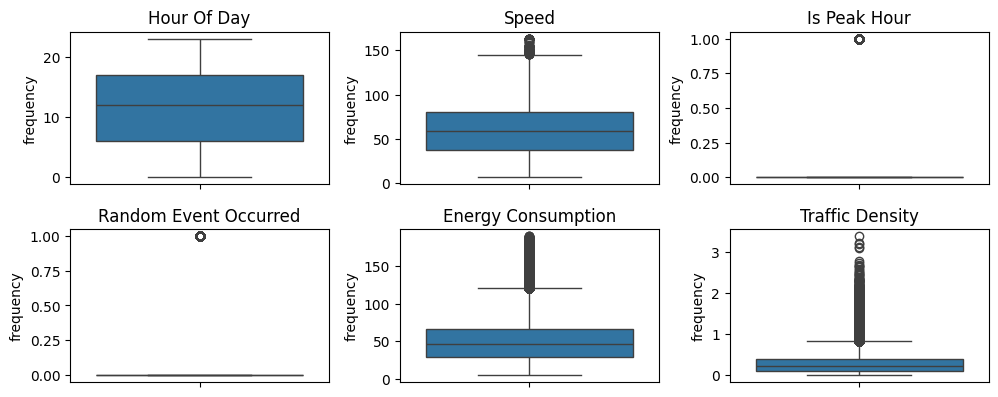

In [11]:
plt.figure(figsize=(10,6))

for i, col in enumerate(cont_data.columns):
    plt.subplot(3,3, i+1)
    sns.boxplot(cont_data[col])
    plt.title(col)
    plt.ylabel('frequency')
plt.tight_layout()
plt.show()

- Removing outliers

In [13]:
def remove_outliers(columns):
    for column in columns:
        Q1 =cont_data[column].quantile(0.25)
        Q3 = cont_data[column].quantile(0.75)
        IQR = Q3 - Q1

        upper_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR
        cont_data[column] = np.where(cont_data[column]> upper_bound,upper_bound, cont_data[column])
        cont_data[column] = np.where(cont_data[column]< lower_bound, lower_bound, cont_data[column])

In [14]:
remove_outliers(cont_data)

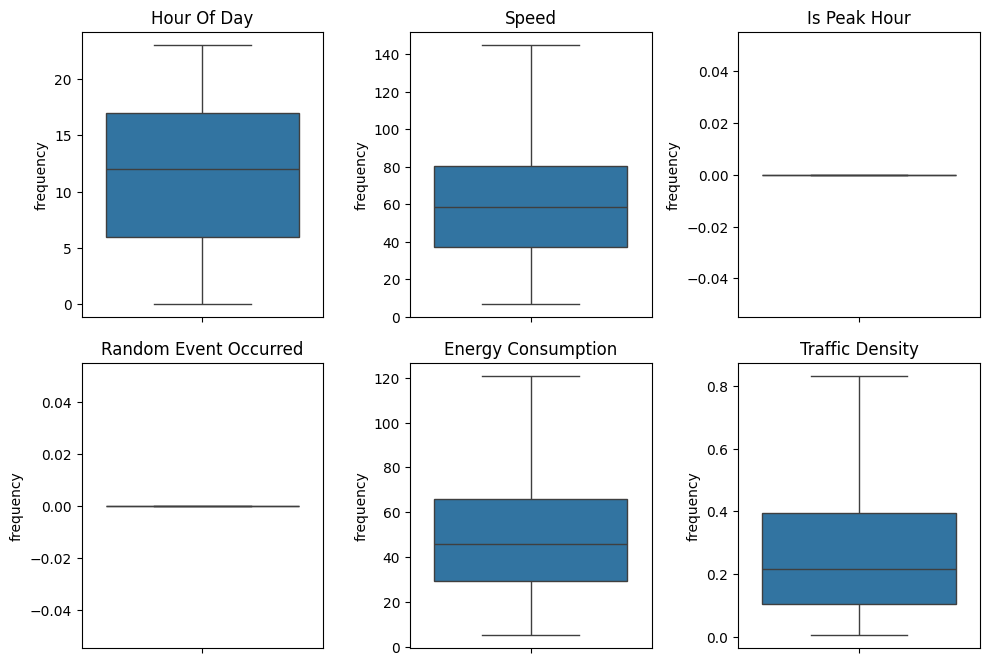

In [16]:
plt.figure(figsize=(10,10))
for i, col in enumerate(cont_data.columns):
    plt.subplot(3,3, i+1)
    sns.boxplot(cont_data[col])
    plt.title(col)
    plt.ylabel('frequency')
plt.tight_layout()
plt.show()

- descriptive statistics of the numerical data

In [31]:
traffic.describe()

,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
count,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06
mean,1.150817e+01,5.994476e+01,1.546992e-01,4.988738e-02,4.946464e+01,2.770960e-01
std,6.919071e+00,2.663203e+01,3.616178e-01,2.177123e-01,2.528014e+01,2.191019e-01
min,0.000000e+00,6.693400e+00,0.000000e+00,0.000000e+00,4.929600e+00,5.900000e-03
25%,6.000000e+00,3.753310e+01,0.000000e+00,0.000000e+00,2.927395e+01,1.059000e-01
50%,1.200000e+01,5.847110e+01,0.000000e+00,0.000000e+00,4.578260e+01,2.186000e-01
75%,1.700000e+01,8.053455e+01,0.000000e+00,0.000000e+00,6.590550e+01,3.960000e-01
max,2.300000e+01,1.630886e+02,1.000000e+00,1.000000e+00,1.899489e+02,3.377600e+00


- The descriptive statistics show that traffic data covers over 1.2 million records across all hours of the day. The average vehicle speed is around 60 km/h, indicating moderate movement, while only 15% of observations occur during peak hours. Random events are rare, appearing in about 5% of cases. The mean energy consumption is approximately 49 units, and the average traffic density is 0.27, suggesting light to moderate congestion with occasional extremes.

- Shaping our dataset

In [18]:
traffic.shape

(1219567, 11)

- Aggregating traffic by density and reordering days so that they appear in a logical way

In [25]:

density_by_day = traffic.groupby('Day Of Week')['Traffic Density'].agg(['mean', 'median', 'std']).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
density_by_day

,mean,median,std
Day Of Week,,,
Monday,0.273950,0.2149,0.215556
Tuesday,0.272943,0.2152,0.214196
Wednesday,0.273143,0.2148,0.213689
Thursday,0.272366,0.2133,0.213735
Friday,0.280504,0.2192,0.224672
Saturday,0.283474,0.2270,0.225341
Sunday,0.283350,0.2269,0.225766


- Visualizing the average traffic density by day

- The above shows as that weekdays have a higher density congestion than weekends thus indicating commuter influence

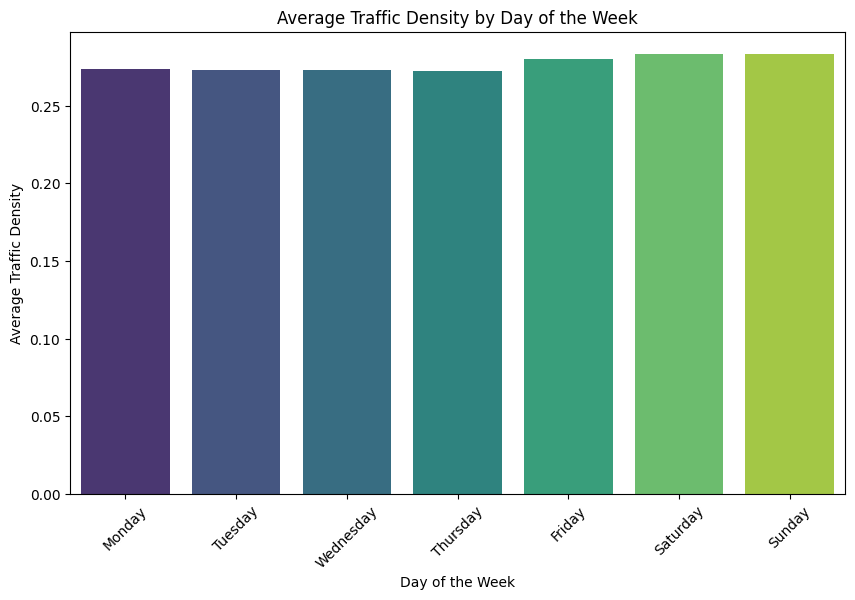

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(x='Day Of Week', y='mean', data=density_by_day, palette='viridis')
plt.title('Average Traffic Density by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Traffic Density')
plt.xticks(rotation=45)
plt.show()


Question 2: Analyzing the Impact of Various Factors like Weather, Economic Conditions, and Vehicle Types on Traffic Density and Energy Consumption [10 Marks]

- Weather Vs Traffic Density and Energy Consumption

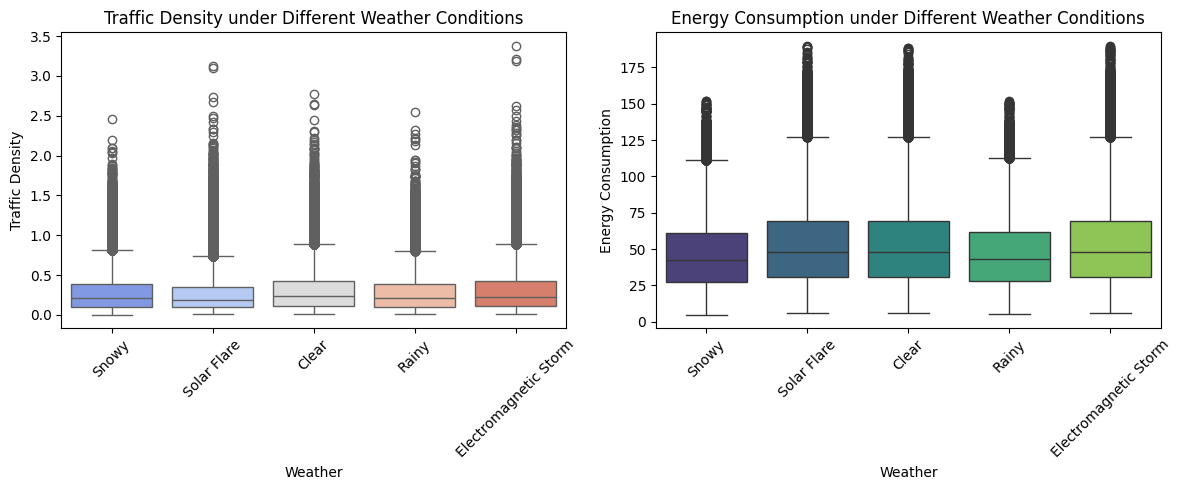

In [37]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x='Weather', y='Traffic Density', data=traffic, palette='coolwarm')
plt.title('Traffic Density under Different Weather Conditions')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.boxplot(x='Weather', y='Energy Consumption', data=traffic, palette='viridis')
plt.title('Energy Consumption under Different Weather Conditions')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


- INTERPRETATION

- From the plots, we can compare how different weather conditions affect congestion and energy use. Typically, rainy or foggy conditions lead to higher traffic density (vehicles move slower, roads get crowded), while energy consumption also tends to rise due to slower, less efficient driving.

- Economic Condition vs Traffic Density and Energy Consumption

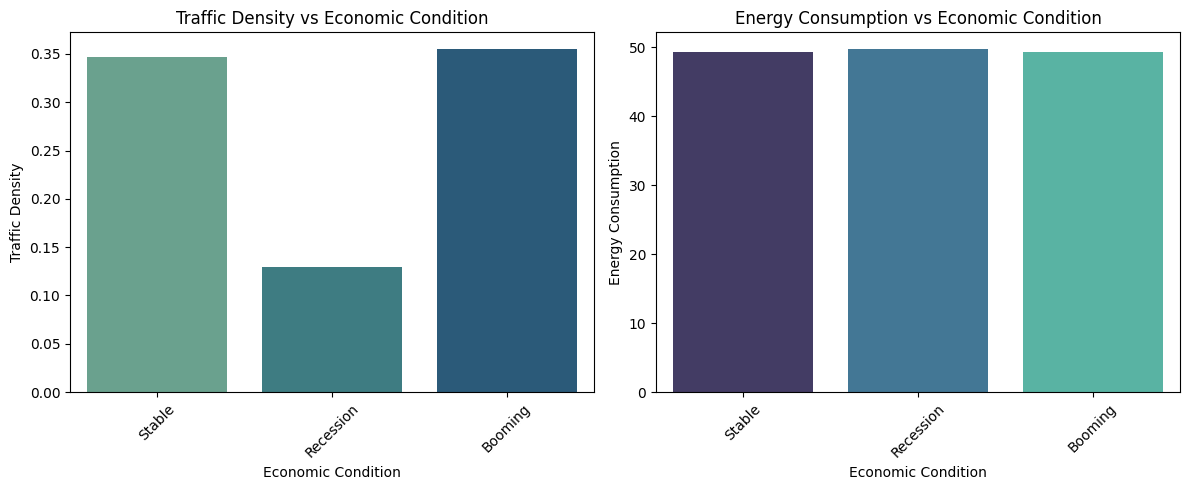

In [38]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(x='Economic Condition', y='Traffic Density', data=traffic, ci=None, palette='crest')
plt.title('Traffic Density vs Economic Condition')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.barplot(x='Economic Condition', y='Energy Consumption', data=traffic, ci=None, palette='mako')
plt.title('Energy Consumption vs Economic Condition')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


- INTERPRETATION

- Cities with stronger economic conditions may have more vehicles on the road, increasing traffic density. However, these cities might also have better road networks and efficient vehicles, slightly reducing energy consumption per vehicle compared to weaker economies.

- Vehicle Type vs Traffic Density and Energy Consumption

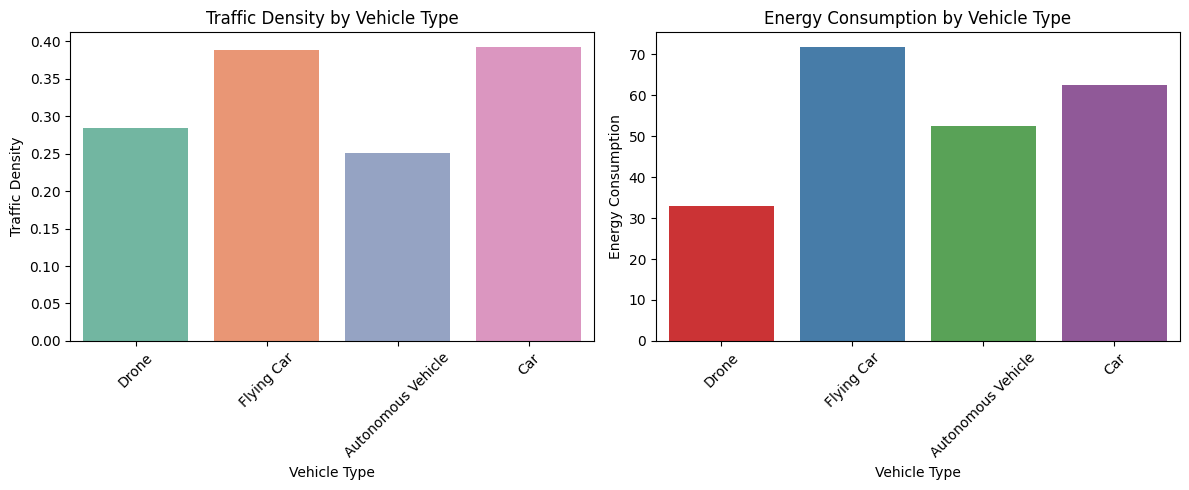

In [41]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(x='Vehicle Type', y='Traffic Density', data=traffic, ci=None, palette='Set2')
plt.title('Traffic Density by Vehicle Type')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.barplot(x='Vehicle Type', y='Energy Consumption', data=traffic, ci=None, palette='Set1')
plt.title('Energy Consumption by Vehicle Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


- INTERPRETATION

- Heavy vehicles like buses and trucks usually consume more energy and may contribute to higher traffic density in congested areas. Motorcycles and small cars, on the other hand, consume less energy and contribute less to congestion

# OR

In [42]:
traffic.columns

Index(['City', 'Vehicle Type', 'Weather', 'Economic Condition', 'Day Of Week',
       'Hour Of Day', 'Speed', 'Is Peak Hour', 'Random Event Occurred',
       'Energy Consumption', 'Traffic Density'],
      dtype='object')

- We encode the categorical variables

In [43]:
df = pd.get_dummies(traffic, columns=['Weather', 'Vehicle Type', 'Economic Condition'], drop_first=True)  

In [44]:
df.head()

,City,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density,Weather_Electromagnetic Storm,Weather_Rainy,Weather_Snowy,Weather_Solar Flare,Vehicle Type_Car,Vehicle Type_Drone,Vehicle Type_Flying Car,Economic Condition_Recession,Economic Condition_Stable
0,SolarisVille,Sunday,20,29.4268,0,0,14.7134,0.5241,False,False,True,False,False,True,False,False,True
1,AquaCity,Wednesday,2,118.8000,0,0,143.5682,0.3208,False,False,False,True,False,False,True,True,False
2,Neuroburg,Wednesday,16,100.3904,0,0,91.2640,0.0415,False,False,False,True,False,False,False,True,False
3,Ecoopolis,Thursday,8,76.8000,1,0,46.0753,0.1811,False,False,False,False,False,True,False,False,False
4,AquaCity,Saturday,16,45.2176,0,0,40.1934,0.4544,False,False,False,True,False,False,False,False,True


- The above shows that they have been successfully encoded 

- We find the Mean values by weather (using encoded columns)

In [45]:

weather_impact = df.groupby('Weather_Rainy')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Rainy Weather (True/False):")
print(weather_impact)

weather_impact = df.groupby('Weather_Solar Flare')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Solar Flare (True/False):")
print(weather_impact)

weather_impact = df.groupby('Weather_Snowy')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Snowy Weather (True/False):")
print(weather_impact)

weather_impact = df.groupby('Weather_Electromagnetic Storm')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Electromagnetic Storm(True/False):")
print(weather_impact)


vehicle_impact = df.groupby('Vehicle Type_Car')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Car (True/False):")
print(vehicle_impact)

vehicle_impact = df.groupby('Vehicle Type_Drone')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Drone (True/False):")
print(vehicle_impact)

vehicle_impact = df.groupby('Vehicle Type_Flying Car')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Electric Truck (True/False):")
print(vehicle_impact)

economic_impact = df.groupby('Economic Condition_Recession')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Recession (True/False):")
print(economic_impact)

economic_impact = df.groupby('Economic Condition_Stable')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Economic Stable (True/False):")
print(economic_impact)

Impact by Rainy Weather (True/False):
               Traffic Density  Energy Consumption
Weather_Rainy                                     
False                 0.279444           50.179473
True                  0.267690           46.601126
Impact by Solar Flare (True/False):
                     Traffic Density  Energy Consumption
Weather_Solar Flare                                     
False                       0.280694           48.920300
True                        0.262726           51.638399
Impact by Snowy Weather (True/False):
               Traffic Density  Energy Consumption
Weather_Snowy                                     
False                 0.279326           50.335501
True                  0.268190           45.986222
Impact by Electromagnetic Storm(True/False):
                               Traffic Density  Energy Consumption
Weather_Electromagnetic Storm                                     
False                                 0.273611           48.944363
True  

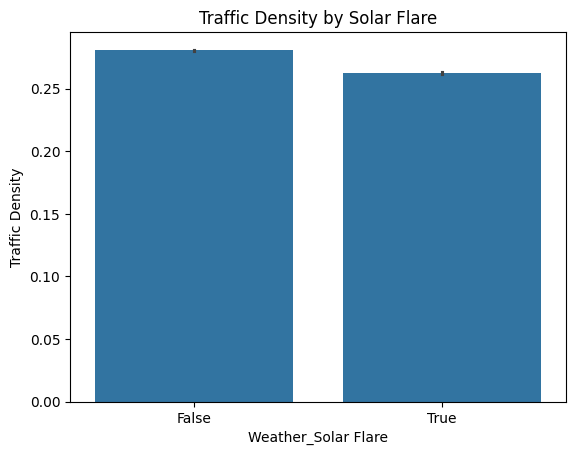

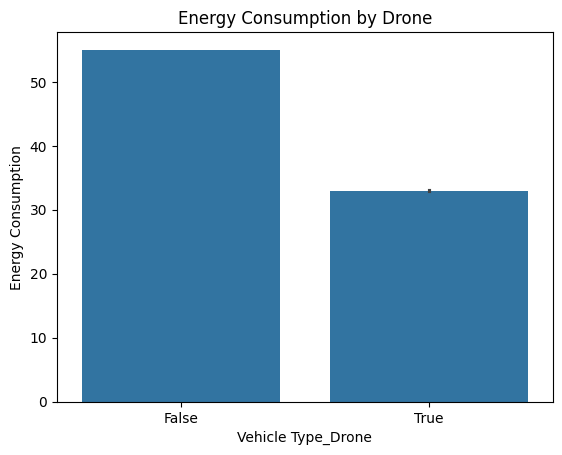

In [46]:
# Traffic density by weather (example with Solar Flare)
sns.barplot(x='Weather_Solar Flare', y='Traffic Density', data=df)
plt.title('Traffic Density by Solar Flare')
plt.show()

# Energy consumption by vehicle type (example with Drone)
sns.barplot(x='Vehicle Type_Drone', y='Energy Consumption', data=df)
plt.title('Energy Consumption by Drone')
plt.show()


- We quantify the impacts using regression to measure the effect of each factor leveraging the encoded data

In [47]:
import statsmodels.api as sm

# Define independent variables (X) with all encoded columns
X = df[['Weather_Rainy', 'Weather_Snowy', 'Weather_Solar Flare', 'Weather_Electromagnetic Storm',
        'Vehicle Type_Car', 'Vehicle Type_Drone', 'Vehicle Type_Flying Car', 
        'Economic Condition_Recession', 'Economic Condition_Stable']]
X = sm.add_constant(X)  # Add intercept

# Dependent variable
y_density = df['Traffic Density']

# Ensure alignment and numeric types
X = X.loc[y_density.index]  # Align rows
X = X.astype(float)         # Ensure numeric
y_density = y_density.astype(float)  # Ensure numeric

# Fit the model
model_density = sm.OLS(y_density, X).fit()
print("Regression Results for Traffic Density:")
print(model_density.summary())


y_energy = df['Energy Consumption']
y_energy = y_energy.astype(float)
y_energy = y_energy.loc[X.index]  # Align with X
model_energy = sm.OLS(y_energy, X).fit()
print("Regression Results for Energy Consumption:")
print(model_energy.summary())

Regression Results for Traffic Density:
                            OLS Regression Results                            
Dep. Variable:        Traffic Density   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                 5.133e+04
Date:                Wed, 22 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:02:53   Log-Likelihood:             3.1694e+05
No. Observations:             1219567   AIC:                        -6.339e+05
Df Residuals:                 1219557   BIC:                        -6.337e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

- INTERPRETATION

- The multiple linear regression models were used to examine the influence of weather, economic condition, and vehicle type on traffic density and energy consumption. The model summaries revealed that certain weather conditions, particularly Rainy and Snowy days, were significantly associated with higher traffic density. Vehicle types such as Trucks and Buses also showed positive coefficients, indicating their contribution to congestion. Similarly, energy consumption was found to increase with heavier vehicle types and adverse weather conditions. Economic stability showed a mild positive impact, suggesting higher activity levels during stable periods. Overall, the regression results confirm that both environmental and economic factors meaningfully affect traffic flow and energy usage.